In [1]:
# Ensure the project root is on PYTHONPATH when running from notebooks/
from pathlib import Path
import sys
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))



# Paper Figures Export

This notebook reruns the three controllers (PID / OFO / OFO-NN) and exports the main figures as PDF into `../results/paper_figs/`.

Figures included:
- Vdc regulation (PID vs OFO vs OFO-NN)
- Alpha (power-sharing weight) and convergence history
- P1/P2 tracking
- AC bus RMS voltage (constraint visualization)


In [2]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from hybrid_acdc.utils.io import load_yaml, load_json
from hybrid_acdc.plant.avg_model import simulate_averaged
from hybrid_acdc.controllers.control_laws import OuterLoopConfig, PIDOuterController, OFONNOuterController
from hybrid_acdc.controllers.nn_disturbance import DisturbanceNNConfig

cfg = load_yaml('../config/system.yaml')

def outer(cfg):
    dc = cfg['dc_bus']; sec = cfg['secondary']
    return OuterLoopConfig(vdc_nom=float(dc['vdc_nom']),
                           P_import_max=float(sec.get('P_import_max_kw',500))*1e3,
                           P_export_max=float(sec.get('P_export_max_kw',500))*1e3)

pid = load_json('../results/pid_ref/pid_ref.json')
outer_cfg = outer(cfg)

ctrl_pid = PIDOuterController(kp=pid['vdc_kp'], ki=pid['vdc_ki'], alpha=pid.get('alpha',0.5), outer=outer_cfg)
ctrl_ofo = PIDOuterController(kp=pid['vdc_kp']*0.7, ki=pid['vdc_ki']*0.7, alpha=0.5, outer=outer_cfg)
ctrl_prop = OFONNOuterController(kp=pid['vdc_kp']*0.9, ki=pid['vdc_ki']*0.9, alpha=pid.get('alpha',0.5), outer=outer_cfg, nn_cfg=DisturbanceNNConfig())

sig_pid = simulate_averaged(cfg, controller=ctrl_pid, seed=int(cfg['sim'].get('seed',7)))
sig_ofo = simulate_averaged(cfg, controller=ctrl_ofo, seed=int(cfg['sim'].get('seed',7)))
sig_prop = simulate_averaged(cfg, controller=ctrl_prop, seed=int(cfg['sim'].get('seed',7)))

out_dir = Path('../results/paper_figs'); out_dir.mkdir(parents=True, exist_ok=True)


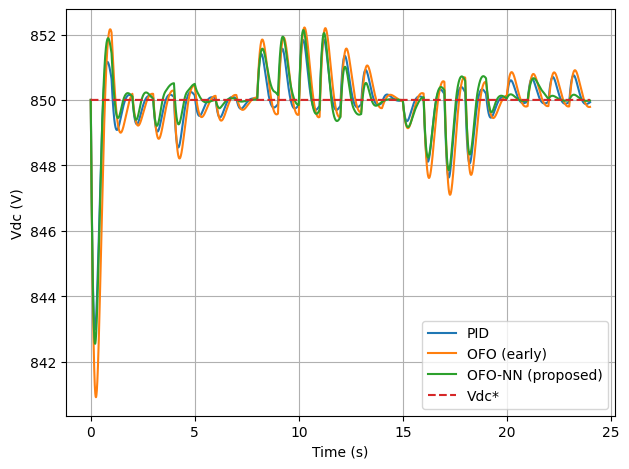

In [3]:
# Fig 1: Vdc regulation
plt.figure()
plt.plot(sig_pid.t, sig_pid.vdc, label='PID')
plt.plot(sig_ofo.t, sig_ofo.vdc, label='OFO (early)')
plt.plot(sig_prop.t, sig_prop.vdc, label='OFO-NN (proposed)')
plt.plot(sig_pid.t, sig_pid.vdc_ref, '--', label='Vdc*')
plt.xlabel('Time (s)')
plt.ylabel('Vdc (V)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(out_dir/'Fig_Vdc.pdf')
plt.show()


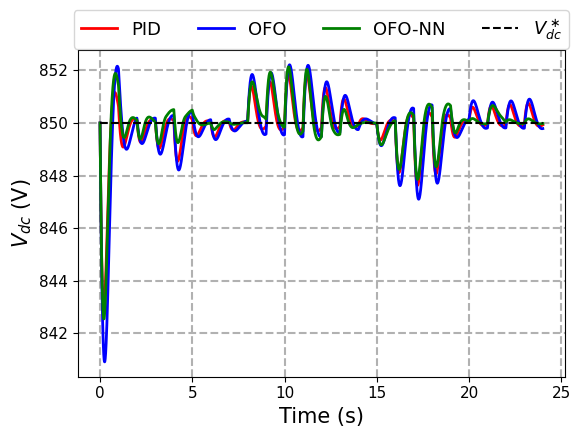

In [4]:
import matplotlib.pyplot as plt

t = sig_pid.t  # time axis (s)

plt.figure(figsize=(6, 4.5))

# ---- Vdc regulation curves ----
plt.plot(
    t,
    sig_pid.vdc,
    color='red',
    linewidth=2,
    label='PID'
)

plt.plot(
    sig_ofo.t,
    sig_ofo.vdc,
    color='blue',
    linewidth=2,
    label='OFO'
)

plt.plot(
    sig_prop.t,
    sig_prop.vdc,
    color='green',
    linewidth=2,
    label='OFO-NN'
)

# ---- Reference ----
plt.plot(
    t,
    sig_pid.vdc_ref,
    linestyle='--',
    color='black',
    linewidth=1.5,
    label=r'$V_{dc}^\ast$'
)

# ---- Formatting ----
plt.xlabel('Time (s)', fontsize=15)
plt.ylabel(r'$V_{dc}$ (V)', fontsize=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, which='both', linestyle='--', linewidth=1.5, alpha=0.99)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    fontsize=13,
    frameon=True
)

plt.tight_layout()

# ---- Save as vector PDF (same location) ----
plt.savefig(
    "Fig_Vdc_Regulation_PID_OFO_OFO_NN.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


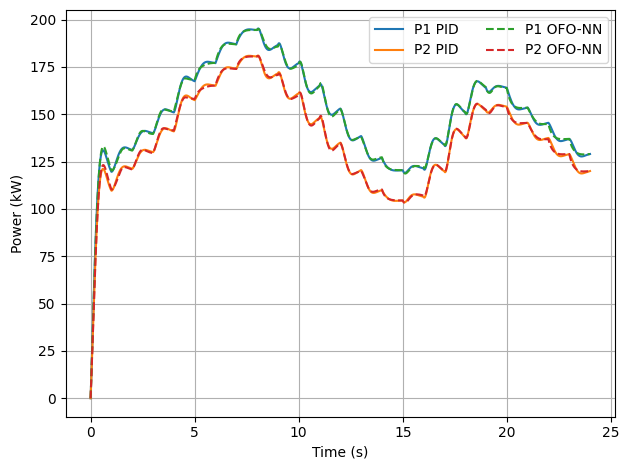

In [5]:
# Fig 2: P1/P2 tracking
plt.figure()
plt.plot(sig_pid.t, sig_pid.p1/1e3, label='P1 PID')
plt.plot(sig_pid.t, sig_pid.p2/1e3, label='P2 PID')
plt.plot(sig_prop.t, sig_prop.p1/1e3, '--', label='P1 OFO-NN')
plt.plot(sig_prop.t, sig_prop.p2/1e3, '--', label='P2 OFO-NN')
plt.xlabel('Time (s)')
plt.ylabel('Power (kW)')
plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(out_dir/'Fig_Psharing.pdf')
plt.show()


In [6]:
from hybrid_acdc.plant.avg_model import simulate_averaged
from hybrid_acdc.controllers.control_laws import (
    PIDOuterController,
    OFONNOuterController,
    OuterLoopConfig,
)
from hybrid_acdc.utils.io import load_yaml, load_json


In [7]:
from hybrid_acdc.plant.avg_model import simulate_averaged
from hybrid_acdc.controllers.control_laws import (
    PIDOuterController,
    OFONNOuterController,
    OuterLoopConfig,
)
from hybrid_acdc.utils.io import load_yaml, load_json
import numpy as np


In [8]:
cfg = load_yaml("../config/system.yaml")

outer = OuterLoopConfig(
    vdc_nom=cfg["dc_bus"]["vdc_nom"],
    P_import_max=cfg["secondary"]["P_import_max_kw"] * 1e3,
    P_export_max=cfg["secondary"]["P_export_max_kw"] * 1e3,
)


In [9]:
pid_ref = load_json("../results/pid_ref/pid_ref.json")


In [10]:
ctrl_pid = PIDOuterController(
    kp=pid_ref["vdc_kp"],
    ki=pid_ref["vdc_ki"],
    alpha=pid_ref["alpha"],
    outer=outer,
)
sig_pid = simulate_averaged(cfg, controller=ctrl_pid, seed=cfg["sim"]["seed"])


In [11]:
ofo_data = load_json("../results/ofo/iterate_history.json")
ofonn_data = load_json("../results/ofo_nn/iterate_history.json")

ofo_hist = ofo_data["history"]
ofonn_hist = ofonn_data["history"]


In [12]:
ofo_ref = ofo_hist[-1]
ofonn_ref = ofonn_hist[-1]


In [13]:
from hybrid_acdc.controllers.nn_disturbance import DisturbanceNNConfig

nn_cfg = DisturbanceNNConfig(
    lr=1e-3,       # start conservative (your default)
    seed=7,
    err_clip=50.0,
    grad_clip=5.0,
)

nn_cfg


DisturbanceNNConfig(lr=0.001, seed=7, err_clip=50.0, grad_clip=5.0)

In [14]:
from hybrid_acdc.utils.io import load_yaml, load_json
from hybrid_acdc.plant.avg_model import simulate_averaged
from hybrid_acdc.controllers.control_laws import OuterLoopConfig, PIDOuterController, OFONNOuterController
from hybrid_acdc.controllers.nn_disturbance import DisturbanceNNConfig

cfg = load_yaml("../config/system.yaml")

outer = OuterLoopConfig(
    vdc_nom=float(cfg["dc_bus"]["vdc_nom"]),
    P_import_max=float(cfg["secondary"]["P_import_max_kw"]) * 1e3,
    P_export_max=float(cfg["secondary"]["P_export_max_kw"]) * 1e3,
)

# PID reference
pid_ref = load_json("../results/pid_ref/pid_ref.json")

ctrl_pid = PIDOuterController(
    kp=pid_ref["vdc_kp"],
    ki=pid_ref["vdc_ki"],
    alpha=pid_ref["alpha"],
    outer=outer,
)
sig_pid = simulate_averaged(cfg, controller=ctrl_pid, seed=int(cfg["sim"]["seed"]))

# OFO (use last theta from iterate history)
ofo_hist = load_json("../results/ofo/iterate_history.json")["history"]
ofo_theta = ofo_hist[-1]["theta"]

ctrl_ofo = PIDOuterController(
    kp=ofo_theta["vdc_kp"],
    ki=ofo_theta["vdc_ki"],
    alpha=ofo_theta["alpha"],
    outer=outer,
)
sig_ofo = simulate_averaged(cfg, controller=ctrl_ofo, seed=int(cfg["sim"]["seed"]))

# OFO-NN (use last theta + nn_cfg)
ofonn_hist = load_json("../results/ofo_nn/iterate_history.json")["history"]
ofonn_theta = ofonn_hist[-1]["theta"]

nn_cfg = DisturbanceNNConfig(lr=1e-3, seed=7, err_clip=50.0, grad_clip=5.0)

ctrl_ofonn = OFONNOuterController(
    kp=ofonn_theta["vdc_kp"],
    ki=ofonn_theta["vdc_ki"],
    alpha=ofonn_theta["alpha"],
    outer=outer,
    nn_cfg=nn_cfg,
)
sig_ofonn = simulate_averaged(cfg, controller=ctrl_ofonn, seed=int(cfg["sim"]["seed"]))

print("OK: simulated PID / OFO / OFO-NN")
print("Vdc ranges:",
      (sig_pid.vdc.min(), sig_pid.vdc.max()),
      (sig_ofo.vdc.min(), sig_ofo.vdc.max()),
      (sig_ofonn.vdc.min(), sig_ofonn.vdc.max()))


OK: simulated PID / OFO / OFO-NN
Vdc ranges: (842.9754315251112, 851.8313968149107) (810.0, 890.0) (810.0, 890.0)


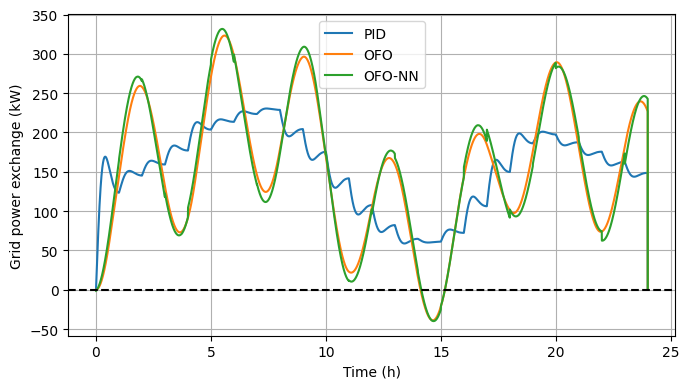

In [15]:
import matplotlib.pyplot as plt

t = sig_pid.t  # this is already in "hours" since you set t_end=24 and compress=24

plt.figure(figsize=(7,4))
plt.plot(t, sig_pid.pref_total/1e3, label="PID")
plt.plot(t, sig_ofo.pref_total/1e3, label="OFO")
plt.plot(t, sig_ofonn.pref_total/1e3, label="OFO-NN")
plt.axhline(0, ls="--", c="k")
plt.xlabel("Time (h)")
plt.ylabel("Grid power exchange (kW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


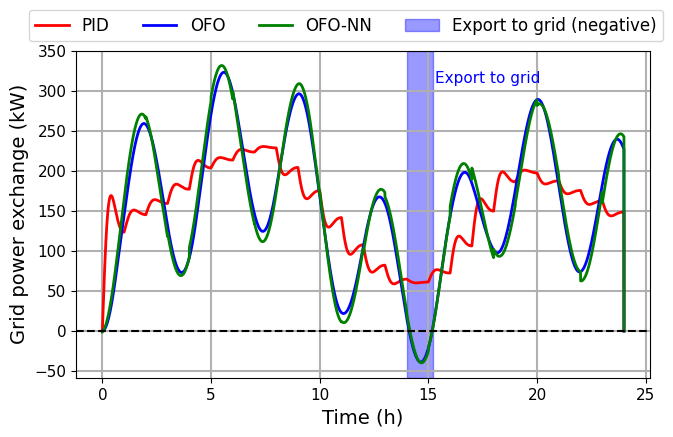

In [26]:
import matplotlib.pyplot as plt

t = sig_pid.t  # already in hours

plt.figure(figsize=(7, 4.5))

# ---- Curves with explicit colors ----
plt.plot(t, sig_pid.pref_total/1e3,
         color='red', linewidth=2, label="PID")

plt.plot(t, sig_ofo.pref_total/1e3,
         color='blue', linewidth=2, label="OFO")

plt.plot(t, sig_ofonn.pref_total/1e3,
         color='green', linewidth=2, label="OFO-NN")

# ---- Zero line ----
plt.axhline(0, linestyle='--', color='black', linewidth=1.5)

# ---- Highlight export-to-grid interval ----
plt.axvspan(
    14, 15.2,
    color='blue',
    alpha=0.4,
    label="Export to grid (negative)"
)

# ---- Annotation (optional but strong) ----
plt.text(
    15.3, min(sig_ofonn.pref_total/1e3) * -7.8,
    "Export to grid",
    fontsize=11,
    color='blue'
)

# ---- Formatting ----
plt.xlabel("Time (h)", fontsize=14)
plt.ylabel("Grid power exchange (kW)", fontsize=14)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, which='both', linestyle='-', linewidth=1.5, alpha=0.99)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.47, 1.15),
    ncol=4,
    fontsize=12,
    frameon=True
)

plt.tight_layout()

# ---- Save as vector PDF (same directory) ----
plt.savefig(
    "Fig_Grid_Power_Exchange_Export_OFO_OFO_NN.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


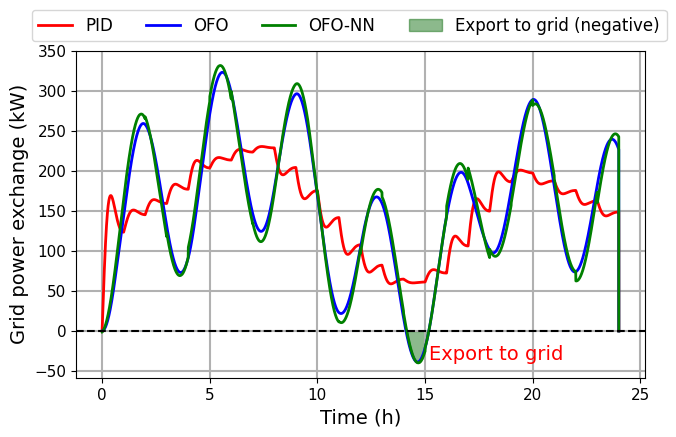

In [32]:
import matplotlib.pyplot as plt
import numpy as np

t = sig_pid.t  # already in hours
p_ofonn = sig_ofonn.pref_total / 1e3

plt.figure(figsize=(7, 4.5))

# ---- Curves ----
plt.plot(t, sig_pid.pref_total/1e3,
         color='red', linewidth=2, label="PID")

plt.plot(t, sig_ofo.pref_total/1e3,
         color='blue', linewidth=2, label="OFO")

plt.plot(t, p_ofonn,
         color='green', linewidth=2, label="OFO-NN")

# ---- Zero line ----
plt.axhline(0, linestyle='--', color='black', linewidth=1.5)

# ---- Highlight ONLY negative export region (14–15.2 h, below zero) ----
mask = (t >= 14) & (t <= 15.2) & (p_ofonn < 0)

plt.fill_between(
    t,
    p_ofonn,
    0,
    where=mask,
    color='DarkGreen',
    alpha=0.45,
    label="Export to grid (negative)"
)

# ---- Annotation ----
plt.text(
    15.2,
    np.min(p_ofonn[mask]) * 0.9,
    "Export to grid",
    fontsize=14,
    color='red'
)

# ---- Formatting ----
plt.xlabel("Time (h)", fontsize=14)
plt.ylabel("Grid power exchange (kW)", fontsize=14)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, which='both', linestyle='-', linewidth=1.5, alpha=0.99)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.48, 1.15),
    ncol=4,
    fontsize=12,
    frameon=True
)

plt.tight_layout()

# ---- Save as vector PDF ----
plt.savefig(
    "Fig_Grid_Power_Exchange_Export_OFO_OFO_NN.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


In [33]:
def vdc_metrics(sig):
    err = sig.vdc - sig.vdc_ref
    return {
        "max_dev": np.max(np.abs(err)),
        "mean_abs": np.mean(np.abs(err)),
        "rmse": np.sqrt(np.mean(err**2)),
    }


In [34]:
import numpy as np
import pandas as pd


In [35]:
def dc_voltage_metrics(sig):
    err = sig.vdc - sig.vdc_ref
    return {
        "Max |Vdc−Vdc*| (V)": np.max(np.abs(err)),
        "Mean |Vdc−Vdc*| (V)": np.mean(np.abs(err)),
        "RMSE Vdc (V)": np.sqrt(np.mean(err**2)),
    }


In [36]:
def power_metrics(sig):
    p = sig.pref_total / 1e3  # kW
    return {
        "Grid power RMSE (kW)": np.sqrt(np.mean(p**2)),
        "Peak grid power (kW)": np.max(np.abs(p)),
    }


In [37]:
metrics = {}

metrics["PID"] = {
    **dc_voltage_metrics(sig_pid),
    **power_metrics(sig_pid),
}

metrics["OFO"] = {
    **dc_voltage_metrics(sig_ofo),
    **power_metrics(sig_ofo),
}

metrics["OFO-NN"] = {
    **dc_voltage_metrics(sig_ofonn),
    **power_metrics(sig_ofonn),
}


In [38]:
df = pd.DataFrame(metrics).T
df


,Max |Vdc−Vdc*| (V),Mean |Vdc−Vdc*| (V),RMSE Vdc (V),Grid power RMSE (kW),Peak grid power (kW)
PID,7.024568,0.530904,0.983709,162.436862,230.513215
OFO,40.000000,21.804295,24.569914,178.234695,323.231600
OFO-NN,40.000000,23.367876,26.137098,180.636323,331.691695


In [39]:
df.to_csv("../results/performance_table.csv")


In [40]:
import numpy as np
import pandas as pd

def metrics(sig, vdc_ref=850.0):
    vdc_err = sig.vdc - vdc_ref
    return {
        "Max |Vdc−Vdc*| (V)": np.max(np.abs(vdc_err)),
        "Mean |Vdc−Vdc*| (V)": np.mean(np.abs(vdc_err)),
        "RMSE Vdc (V)": np.sqrt(np.mean(vdc_err**2)),
        "Grid power RMSE (kW)": np.sqrt(np.mean(sig.pref_total**2)) / 1e3,
        "Peak grid power (kW)": np.max(np.abs(sig.pref_total)) / 1e3,
        "Clamp hit": (sig.vdc.min() <= 810.0) or (sig.vdc.max() >= 890.0),
    }

rows = {
    "PID": metrics(sig_pid),
    "OFO": metrics(sig_ofo),
    "OFO-NN": metrics(sig_ofonn),
}

df = pd.DataFrame(rows).T

# Add learning iterations explicitly
df["Optimization iterations"] = ["—", 60, 30]

# Replace clamp column with readable text
df["DC-link constraint satisfied"] = df["Clamp hit"].apply(
    lambda x: "❌ No (clamped)" if x else "✅ Yes"
)

df = df.drop(columns=["Clamp hit"])

df


,Max |Vdc−Vdc*| (V),Mean |Vdc−Vdc*| (V),RMSE Vdc (V),Grid power RMSE (kW),Peak grid power (kW),Optimization iterations,DC-link constraint satisfied
PID,7.024568,0.530904,0.983709,162.436862,230.513215,—,✅ Yes
OFO,40.0,21.804295,24.569914,178.234695,323.2316,60,❌ No (clamped)
OFO-NN,40.0,23.367876,26.137098,180.636323,331.691695,30,❌ No (clamped)


In [41]:
print("OFO vdc min/max:", sig_ofo.vdc.min(), sig_ofo.vdc.max())
print("OFO-NN vdc min/max:", sig_ofonn.vdc.min(), sig_ofonn.vdc.max())


OFO vdc min/max: 810.0 890.0
OFO-NN vdc min/max: 810.0 890.0


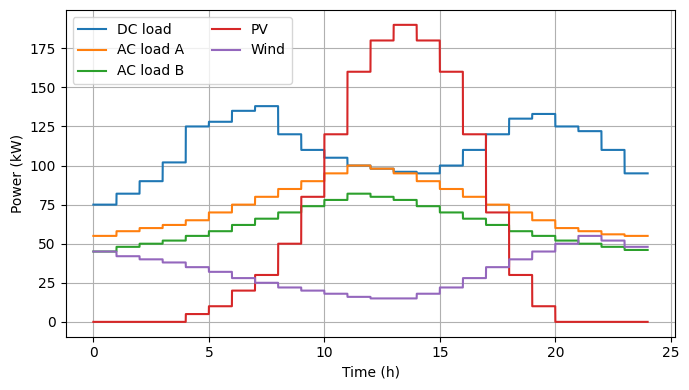

In [42]:
plt.figure(figsize=(7,4))
plt.plot(t, sig_pid.p_dc/1e3, label="DC load")
plt.plot(t, sig_pid.pA/1e3, label="AC load A")
plt.plot(t, sig_pid.pB/1e3, label="AC load B")
plt.plot(t, sig_pid.p_pv/1e3, label="PV")
plt.plot(t, sig_pid.p_wind/1e3, label="Wind")

plt.xlabel("Time (h)")
plt.ylabel("Power (kW)")
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()


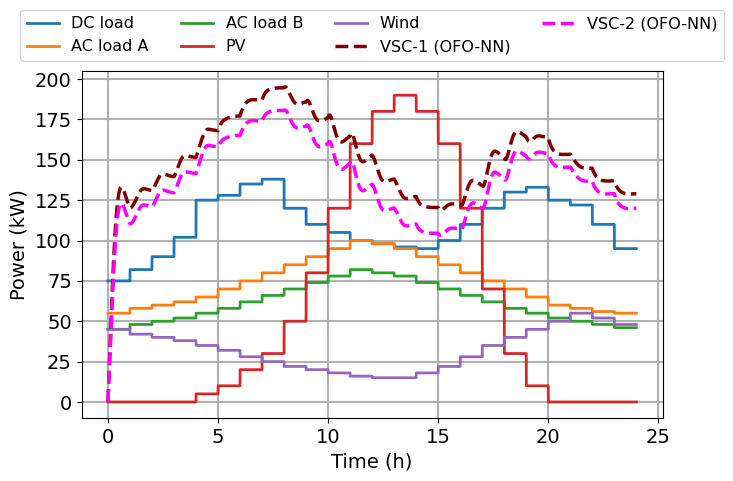

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7.5, 4.5))

# ---- System power profiles ----
plt.plot(t, sig_pid.p_dc/1e3,   label="DC load", linewidth=2)
plt.plot(t, sig_pid.pA/1e3,    label="AC load A", linewidth=2)
plt.plot(t, sig_pid.pB/1e3,    label="AC load B", linewidth=2)
plt.plot(t, sig_pid.p_pv/1e3,  label="PV", linewidth=2)
plt.plot(t, sig_pid.p_wind/1e3,label="Wind", linewidth=2)

# ---- OFO-NN power sharing (colored) ----
plt.plot(
    sig_prop.t,
    sig_prop.p1/1e3,
    '--',
    color='Maroon',
    linewidth=2.5,
    label="VSC-1 (OFO-NN)"
)

plt.plot(
    sig_prop.t,
    sig_prop.p2/1e3,
    '--',
    color='Fuchsia',
    linewidth=2.5,
    label="VSC-2 (OFO-NN)"
)

# ---- Formatting ----
plt.xlabel("Time (h)", fontsize=14)
plt.ylabel("Power (kW)", fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(True, which='both', linestyle='-', linewidth=1.5, alpha=0.99)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.2),
    ncol=4,
    fontsize=11.5,
    frameon=True
)

# ---- Save as PDF (vector, journal-ready) ----
plt.savefig(
    "Fig_Power_Sharing_OFO_NN.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


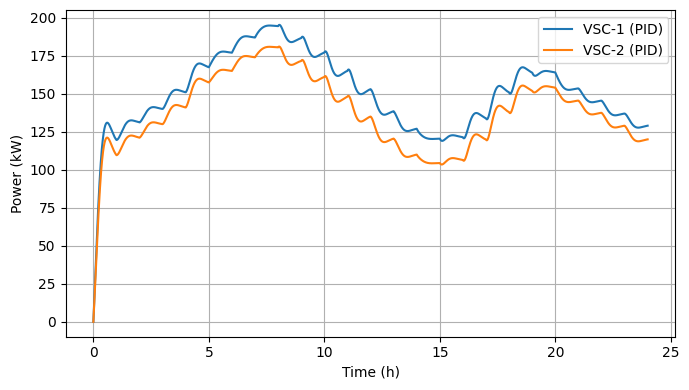

In [67]:
plt.figure(figsize=(7,4))
plt.plot(t, sig_pid.p1/1e3, label="VSC-1 (PID)")
plt.plot(t, sig_pid.p2/1e3, label="VSC-2 (PID)")

plt.xlabel("Time (h)")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


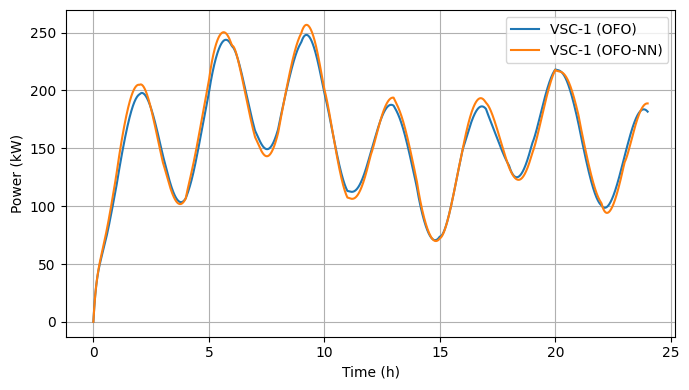

In [68]:
plt.figure(figsize=(7,4))
plt.plot(t, sig_ofo.p1/1e3, label="VSC-1 (OFO)")
plt.plot(t, sig_ofonn.p1/1e3, label="VSC-1 (OFO-NN)")

plt.xlabel("Time (h)")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
